In [1]:
import numpy as np
import pandas as pd
import dask.dataframe as dd
import matplotlib.pyplot as plt
import numpy as np
import gc
import matplotlib.pyplot as plt



from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.model_selection import train_test_split, cross_validate
from sklearn.metrics import accuracy_score
from sklearn.feature_selection import SelectKBest, f_classif

import numpy as np
from sklearn.experimental import enable_halving_search_cv  # noqa
from sklearn.model_selection import HalvingRandomSearchCV
from sklearn.metrics import accuracy_score
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

import utils_ml

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


In [ ]:
plt.style.use('tableau-colorblind10')
def plot_style():
    font_size       = 12
    dpi             = 200

    params = {'figure.dpi': dpi,
              'savefig.dpi': dpi,
              'font.size': font_size,
              'font.family': "serif",
              'figure.titlesize': font_size,
              'legend.fontsize': font_size,
              'axes.labelsize': font_size,
              'axes.titlesize': font_size,
              'xtick.labelsize': font_size,
              'ytick.labelsize': font_size,
              'text.usetex': True,
             }

    plt.rcParams.update(params)
plot_style()

In [2]:
# Load and concatenate all features
file_prefix = "dataExt/P"
file_suffix = "_intensity.pkl"
num_files = 35

label_arr = np.array([np.tile(i,np.load(f"{file_prefix}{0:02d}{file_suffix}", allow_pickle=True).shape[0]) for i in np.arange(num_files)]).flatten()

# Define the mapping from class labels (0 to 7) to the new 3-element array format
# where each element in the array represents the number of poles on [bt], [bb], and [tb]
class_to_poles = {
    0: [0, 0, 0],  # 1 pole on [bt]
    1: [1, 0, 0],  # 1 pole on [bb]
    2: [0, 1, 0],  # 1 pole on [tb]
    3: [0, 0, 1],  # 1 pole on [bt] and 1 pole on [bb]
    4: [2, 0, 0],  # 1 pole on [bb] and 1 pole on [tb]
    5: [0, 2, 0],  # 1 pole on each of [bt], [bb], and [tb]
    6: [0, 0, 2],  # 2 poles on [bb] and 1 pole on [tb]
    7: [1, 1, 0],   # 1 pole on [bb] and 2 poles on [tb]
    8: [1, 0, 1],
    9: [0, 1, 1],
    10: [3, 0, 0],
    11: [0, 3, 0],
    12: [0, 0, 3],
    13: [2, 1, 0],
    14: [2, 0, 1],
    15: [1, 2, 0],
    16: [0, 2, 1],
    17: [1, 0, 2],
    18: [0, 1, 2],
    19: [1, 1, 1],
    20: [4, 0, 0],
    21: [0, 4, 0],
    22: [0, 0, 4],
    23: [3, 1, 0],
    24: [3, 0, 1],
    25: [1, 3, 0],
    26: [0, 3, 1],
    27: [1, 0, 3],
    28: [0, 1, 3],
    29: [2, 2, 0],
    30: [2, 0, 2],
    31: [0, 2, 2],
    32: [2, 1, 1],
    33: [1, 2, 1],
    34: [1, 1, 2],
}


# Later, load the saved array in memory-mapped mode
features_memmap = np.load('dataExt/features_filtered.npy', mmap_mode='r+')



### tune hyperparameters

In [3]:
# Train-test split
# X_train_old, X_test_old, y_train, y_test = train_test_split(all_features, label_arr, test_size=0.1, random_state=42)
X_train_new, X_test_new, y_train, y_test = train_test_split(features_memmap, label_arr, test_size=0.1, random_state=42)

In [4]:
hyp = False
if hyp:

    # Define the model
    model = HistGradientBoostingClassifier()

    # Define the parameter grid with a large search space
    param_grid = {
        'learning_rate': np.logspace(-3, 0, 10),     # Learning rates between 0.001 and 1
        'max_iter': [50, 100, 200, 300],             # Number of boosting iterations
        'max_leaf_nodes': [10, 20, 31, 50, 100],     # Number of leaves in trees
        'min_samples_leaf': [10, 20, 30, 50, 100],   # Minimum samples per leaf
        'l2_regularization': np.logspace(-3, 1, 5)   # Regularization strength
    }

    # Define the halving search with cross-validation
    halving_search = HalvingRandomSearchCV(
        estimator=model,
        param_distributions=param_grid,
        factor=2,                       # Halving factor (reduces candidate space by half each iteration)
        cv=5,                           # 5-fold cross-validation
        scoring='accuracy',
        random_state=42,
        n_jobs=1,                       # Use all available CPU cores,
        verbose = 1
    )

    # Perform the halving search
    halving_search.fit(X_train_new, y_train)

    # Print the best parameters and score
    print("Best parameters found: ", halving_search.best_params_)
    print("Best cross-validation accuracy: {:.2f}".format(halving_search.best_score_))

    # Evaluate the best model on the test set
    best_model = halving_search.best_estimator_
    test_accuracy = accuracy_score(y_test, best_model.predict(X_test_new))
    print("Test accuracy: {:.2f}".format(test_accuracy))


In [5]:
# Initialize the model
# model_old = HistGradientBoostingClassifier(random_state=42)
model_new = HistGradientBoostingClassifier(**{'min_samples_leaf': 20, 'max_leaf_nodes': 50, 'max_iter': 300, 'learning_rate': np.float64(0.1), 'l2_regularization': np.float64(0.001),'random_state':42})


# cv_old = cross_validate(model_old, X_train_old, y_train, cv=5, scoring='accuracy', return_estimator=True)
cv_new = cross_validate(model_new, X_train_new, y_train, cv=5, scoring='accuracy', return_estimator=True)

In [6]:
# rmse = cv_old["test_score"]
# print(f"Validation Accuracy Old Data = {rmse.mean():.3f} +/- {rmse.std():.3f}")

rmse = cv_new["test_score"]
print(f"Validation Accuracy New Data = {rmse.mean():.4f} +/- {rmse.std():.3f}")

Validation Accuracy New Data = 0.6654 +/- 0.010


In [7]:
# old_test_arr = np.zeros(5)
new_test_arr = np.zeros(5)

# for cnt,est in enumerate(cv_old["estimator"]):
#     old_test_arr[cnt] = accuracy_score(y_test, est.predict(X_test_old))

for cnt,est in enumerate(cv_new["estimator"]):
    new_test_arr[cnt] = accuracy_score(y_test, est.predict(X_test_new))

# print(f"Old Dataset - Test Accuracy: {np.mean(old_test_arr):.4f} ± {np.std(old_test_arr):.4f}")
print(f"New Dataset - Test Accuracy: {np.mean(new_test_arr):.4f} ± {np.std(new_test_arr):.4f}")

New Dataset - Test Accuracy: 0.6669 ± 0.0104


In [8]:

# # Define a range of thresholds to test
# thresholds = np.arange(1, X_train_new.shape[1], 10)  # 50 thresholds between 0 and 0.5
# accuracies = []
# num_features_list = []

# best_accuracy = 0
# best_threshold = 0
# best_num_features = X_train_new.shape[1]

# for threshold in thresholds:
#     selector = SelectKBest(f_classif, k=int(threshold))
#     X_train_selected = selector.fit_transform(X_train_new, y_train)
#     X_test_selected = selector.transform(X_test_new)
    
#     # Initialize and fit a HistGradientBoostingClassifier with isotonic calibration
#     hgb_classifier = HistGradientBoostingClassifier(random_state=42)
#     hgb_classifier.fit(X_train_selected, y_train)
    
#     # Evaluate accuracy
#     y_pred = hgb_classifier.predict(X_test_selected)
#     accuracy = accuracy_score(y_test, y_pred)
    
#     # Keep track of accuracy and number of features
#     num_features = X_train_selected.shape[1]
#     accuracies.append(accuracy)
#     num_features_list.append(num_features)
    
#     # Keep track of the best threshold based on accuracy and feature count
#     if accuracy > best_accuracy or (accuracy == best_accuracy and num_features < best_num_features):
#         best_accuracy = accuracy
#         best_threshold = threshold
#         best_num_features = num_features

# # Plot threshold vs number of features
# plt.figure(figsize=(10, 6))
# plt.plot(num_features_list, accuracies, label="Number of Features", color='blue', marker='o')
# plt.ylabel("Accuracy")
# plt.xlabel("Number of Features")
# plt.title("Threshold vs Number of Features")
# plt.grid(True)

# plt.show()

# # Print the best threshold and accuracy information
# print(f"Best Threshold: {best_threshold:.4f}")
# print(f"Best Accuracy: {best_accuracy:.4f}")
# print(f"Number of Features: {best_num_features}")


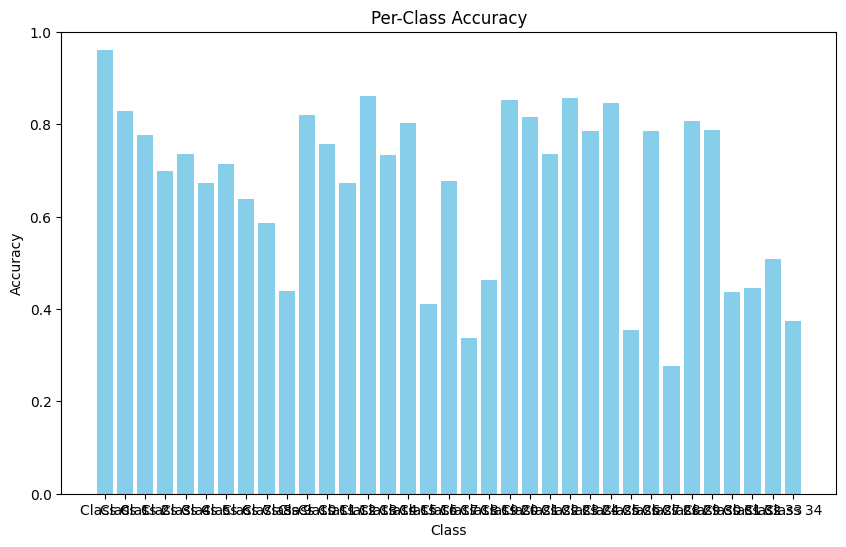

In [11]:
# Number of classes
num_classes = 35

# Calculate accuracy for each class
class_accuracies = []
for cls in range(num_classes):
    # Mask for the current class
    class_mask = (y_test == cls)
    # Calculate accuracy: number of correct predictions for class `cls` / total number of instances of class `cls`
    class_accuracy = np.sum(cv_new["estimator"][0].predict(X_test_new)[class_mask] == y_test[class_mask]) / np.sum(class_mask)
    class_accuracies.append(class_accuracy)

# Convert to numpy array for plotting
class_accuracies = np.array(class_accuracies)

# Bar plot
plt.figure(figsize=(10, 6))
plt.bar(range(num_classes), class_accuracies, color='skyblue')
plt.xlabel('Class')
plt.ylabel('Accuracy')
plt.title('Per-Class Accuracy')
plt.xticks(range(num_classes), [f'Class {i}' for i in range(num_classes)])
plt.ylim(0, 1)  # Accuracy goes from 0 to 1
plt.show()

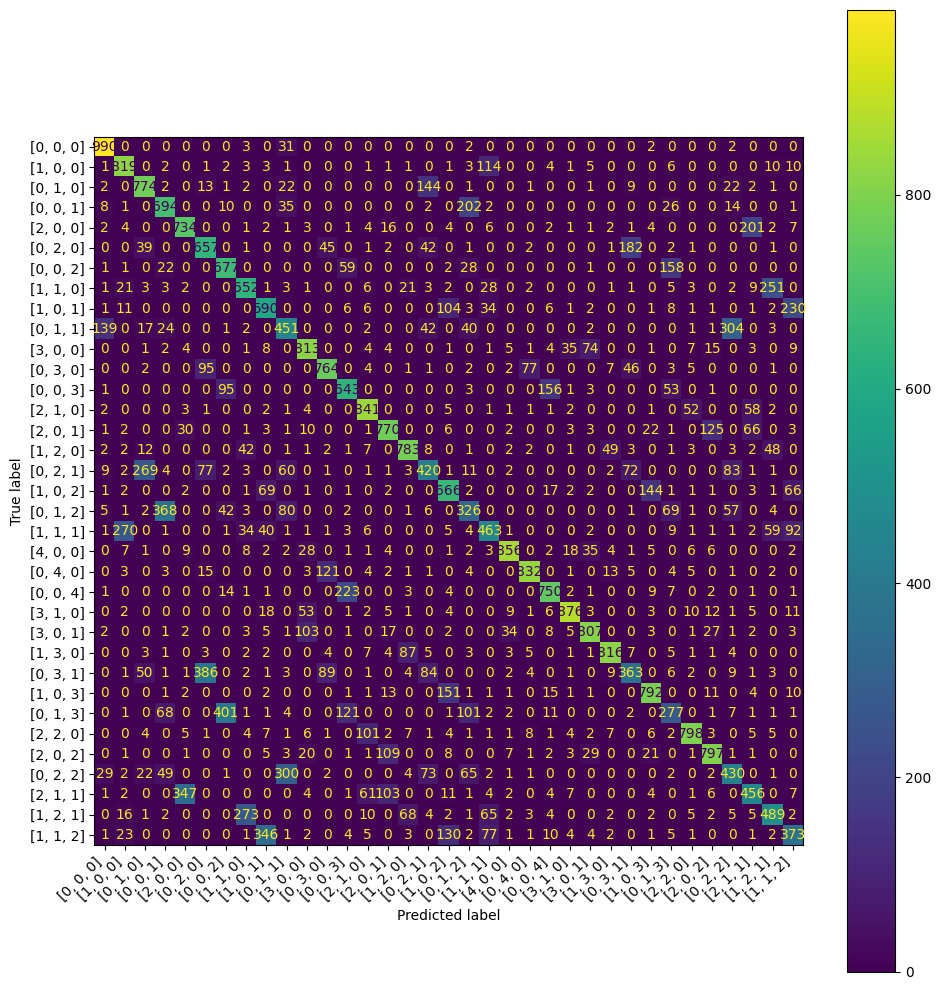

In [12]:


custom_labels = [str(class_to_poles[i]) for i in range(len(class_to_poles))]

# Compute the confusion matrix
predictions = cv_new["estimator"][0].predict(X_test_new)
cm = confusion_matrix(y_test, predictions, labels=np.arange(len(class_to_poles)))

# Plot the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.arange(len(class_to_poles)))
fig, ax = plt.subplots(figsize=(10, 10))  # Adjust figure size if needed
disp.plot(ax=ax)

# Update x and y axis tick labels with the custom labels
ax.set_xticks(np.arange(len(custom_labels)))
ax.set_yticks(np.arange(len(custom_labels)))
ax.set_xticklabels(custom_labels, rotation=45, ha='right', fontsize=10)
ax.set_yticklabels(custom_labels, fontsize=10)

# Adjust layout for readability
plt.tight_layout()
plt.show()